# PROC MDS による携帯キャリアの知覚マッピング

## エグゼクティブサマリー

通信業界の市場調査チームは、顧客が競合する8つの携帯キャリアをどれほど似ていると知覚しているかを測定し、**PROC MDS** を用いて非類似度行列から2次元の知覚マップを復元する。ネットワーク品質と価格/価値という2つの潜在軸は意図的に*独立して*変動するように設計されており、そのため復元されたマップは真に2次元的になる。すなわち、どのブランドが代替品として見られているか、どのブランドが独自のポジショニングを占めているか、そして2つの次元が競争環境をどれだけよく要約しているかを示す。

## データソース

| データセット | 行数 | キー変数 | 説明 |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8(キャリア1社につき1行) | `Carrier`(ID)、`D1`-`D8` | 8つの携帯キャリア間の知覚された非類似度の正方対称行列、0-10スケール(0=知覚上同一、値が大きいほど異なる)。2つの*独立した*軸(ネットワーク品質と価格/価値)上の潜在的な2次元ブランド位置に `rand('NORMAL')` によるサーベイノイズを加えて生成。対角はゼロ。 |

# PROC MDS による携帯キャリアの知覚マッピング

通信業界の市場調査チームは、競合するキャリアがどれほど*似ている*か、あるいは*異なる*かを調査パネルに評価してもらうことが日常的に行われている。こうしたペアワイズの判断は、自然な座標系を持たない**近接性行列**を形成する — しかし**多次元尺度構成法(MDS)**を使えば、2つのブランド間の距離がその知覚された非類似度を再現するような低次元マップを復元できる。

このノートブックでは:

1. 2つの*独立した*ポジショニング軸(ネットワーク品質と価格/価値)から現実的な8キャリアの非類似度行列を合成する。
2. `PROC MDS` で2次元の距離尺度MDSモデルを当てはめる。
3. 復元された座標と適合度不良を読み取り、復元座標から知覚マップを描いて、2つの次元が競争環境をどれだけよく説明するかを判断する。

## ステップ1 - 合成の非類似度行列を構築する

各キャリアを2つの**独立した**軸上の*真の*潜在位置に配置する:

- **ネットワーク品質軸** - プレミアムな全国キャリアは高スコア、格安MVNOは低スコアとなる。
- **価格/価値軸** - バリュー・プリペイド系ブランドは高スコア、プレミアム価格帯のブランドは低スコアとなる。

重要なのは、この2つの軸が8ブランドにわたって無相関であることだ: 高品質なキャリアはプレミアム価格(ノーススター)にも、積極的なバリュー価格(ブルーピーク)にもなり得るし、格安品質のキャリアも価格軸上のどこにでも位置しうる。この独立性こそが、復元されたマップを単一の直線に潰れさせず、真に2次元的なものにする要因である。

2つのキャリア間の知覚された非類似度は、それぞれの潜在位置間のユークリッド距離を0-10のサーベイスケールに再スケールし、対称なサーベイノイズを加えたものである。`PROC MDS` は**正方行列**を期待する: オブジェクト1つにつき1観測、オブジェクト1つにつき1つの数値列で、行の順序と列の順序が一致している必要がある。`D1`-`D8` の列と `Carrier` ラベルを書き出し、行列を対称かつ対角ゼロに強制する。

In [1]:
データ carrier_dissim;
    長さ Carrier $ 30;
    呼出 streaminit(20240517);

    /* 2つの独立した軸上の真の2次元潜在位置:
       qx = ネットワーク品質、px = 価格/価値 (相関 ~ 0) */
    配列 qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    配列 px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);

    /* 対称なノイズ行列。一度だけ生成し、対角はゼロ */
    配列 e[8,8] _temporary_;
    繰返 i = 1 から 8;
        e[i,i] = 0;
        繰返 j = i+1 から 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        終了;
    終了;

    配列 d[8] D1-D8;
    繰返 i = 1 から 8;
        /* キャリア名は非ASCII配列ルックアップの切り捨てを避けるため
           直接 IF/ELSE THEN の代入チェーンで割り当てる */
        もし i = 1 なら Carrier = "ノーススター";
        他 もし i = 2 なら Carrier = "ブルーピーク";
        他 もし i = 3 なら Carrier = "バーテックス";
        他 もし i = 4 なら Carrier = "メトロリンク";
        他 もし i = 5 なら Carrier = "バリューセル";
        他 もし i = 6 なら Carrier = "スリフトモバイル";
        他 もし i = 7 なら Carrier = "センターライン";
        他 Carrier = "ペニーウェーブ";
        繰返 j = 1 から 8;
            dist = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* 潜在距離を 0-10 のサーベイスケールに再スケール */
            d[j] = round( MAX(0, MIN(10, dist*0.85 + e[i,j])), 0.1);
        終了;
        d[i] = 0;            /* ブランドは自分自身と完全に同一 */
        出力;
    終了;

    保持 Carrier D1-D8;
実行;

処理 PRINT データ=carrier_dissim noobs 見出;
    見出 Carrier = 'キャリア';
    表題 '知覚された非類似度マトリクス(0=同一、10=最も異なる)';
実行;

                                             知覚された非類似度マトリクス(0=同一、10=最も異なる)                                              

                    キャリア   D1   D2   D3   D4   D5   D6   D7   D8
ノーススター                      0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
ブルーピーク                    3.5    0  2.5  2.9  5.9    6    2    5
バーテックス                    1.6  2.5    0  1.7  3.6  5.1  3.4    4
メトロリンク                    3.6  2.9  1.7    0  3.1  3.6  1.9    2
バリューセル                    4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
スリフトモバイル                  6.1    6  5.1  3.6  1.8    0  5.3  2.3
センターライン                   5.5    2  3.4  1.9  5.1  5.3    0  2.5
ペニーウェーブ                   6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## ステップ2 - 2次元の距離尺度MDSモデルを当てはめる

非類似度を `LEVEL=INTERVAL`(加法定数を許容する距離尺度MDS)、`DIM=2` でモデル化し、結果を平面上にプロットできるようにする。データは(デフォルトの)非類似度であり、完全な `SQUARE` 行列として格納されている。

主な文と オプション:

- `VAR D1-D8` はオブジェクトごとに1つずつ、8つの列を列挙する。
- `ID Carrier` はブランド名を付与し、出力と `OUT=` 座標に表示されるようにする。
- `OUT=` はオブジェクト座標を取得し(`OCONFIG` で要求)、`OUTFIT=` は適合度不良サマリーを取得する。
- `PCONFIG`、`PFIT`、`PFINAL` は座標、適合統計量、最終パラメータ推定値を出力する。

ステップ3では、復元された `OUT=` 座標から知覚マップを自分たちで描く。これによりブランドラベルや軸スケーリングを完全に制御できる。

In [2]:
処理 mds データ=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    変数 D1-D8;
    id Carrier;
    表題 '携帯キャリア知覚の2次元MDS';
実行;

                                             知覚された非類似度マトリクス(0=同一、10=最も異なる)                                              




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/ef916274-69c8-4151-b5e0-c7f09eb41104/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.71 seconds
  cpu   1.71 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/ef916274-69c8-4151-b5e0-c7f09eb41104/mds_fit.avro (2 rows, 3 columns).


## ステップ3 - 復元された座標を抽出し、マップを描く

`OCONFIG` により、`OUT=` データセットには推定されたオブジェクト座標(キャリア1社につき1行、次元1つにつき1列)が格納される。これらの座標と適合度不良を印刷し、`PROC SGPLOT` で `DIM2` を `DIM1` に対してプロットし、各点にキャリア名でラベルを付けて知覚マップを描画する。

MDS座標は回転・鏡映・一様スケーリングの範囲でしか識別されないため、軸の絶対的な符号は恣意的である。重要なのはブランド間の*相対的な*幾何構造である。回転後は、一方の軸がネットワーク品質を、もう一方が価格/価値を追跡する。

                                                  復元されたMDS配置(オブジェクト座標)                                                  

  Obs  _TYPE_                    _NAME_           DIM1           DIM2
    1  CONFIG  ノーススター                     2.8874230583  -1.8461705276
    2  CONFIG  ブルーピーク                     -0.687559872  -2.8913969565
    3  CONFIG  バーテックス                     1.1117392105  -1.2431470382
    4  CONFIG  メトロリンク                    -0.4552922046  -0.0907948566
    5  CONFIG  バリューセル                     1.6998640261   2.3061186021
    6  CONFIG  スリフトモバイル                  -0.1575406636   3.3768661059
    7  CONFIG  センターライン                   -2.2391140787  -1.1789057517
    8  CONFIG  ペニーウェーブ                   -2.1595194761   1.5674304226

                                                     MDS 適合度不良サマリー                                                      

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

    


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


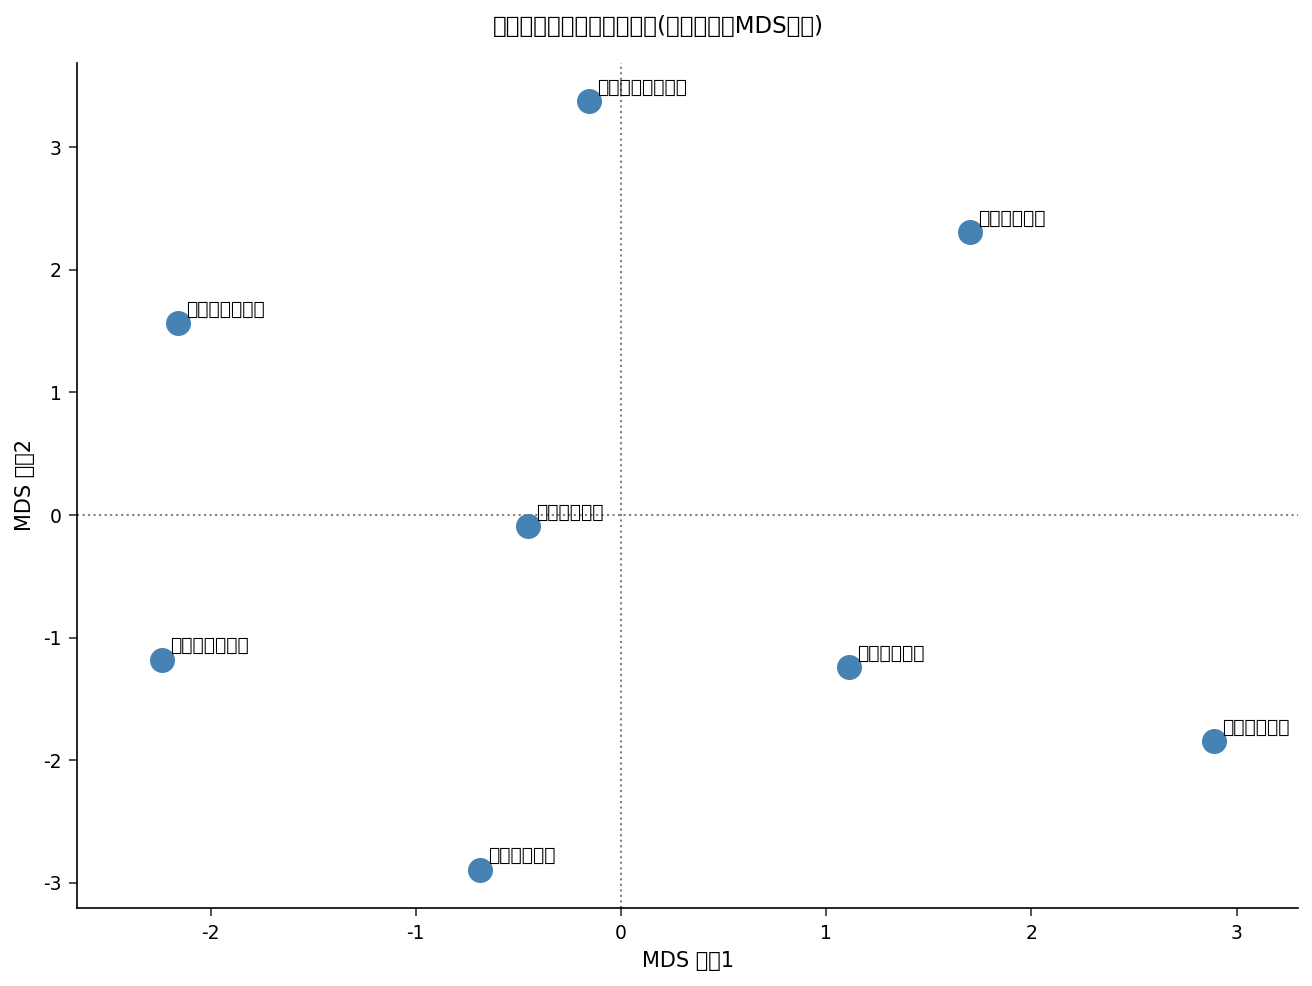

In [3]:
処理 PRINT データ=mds_out 見出;
    表題 '復元されたMDS配置(オブジェクト座標)';
実行;

処理 PRINT データ=mds_fit 見出;
    表題 'MDS 適合度不良サマリー';
実行;

/* 配置行だけを保持し、SGPLOT が各点の隣に印字できるよう
   分かりやすい名前のラベル列をブランドに与える */
データ mds_config;
    設定 mds_out;
    条件 _TYPE_ = 'CONFIG';
    長さ Brand $ 30;
    Brand = _NAME_;
    保持 Brand DIM1 DIM2;
実行;

/* 復元された座標から知覚マップを描き、各マーカーに
   キャリア名でラベルを付ける */
処理 SGPLOT データ=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS 見出='MDS 次元1';
    YAXIS 見出='MDS 次元2';
    表題 '携帯キャリアの知覚マップ(復元されたMDS配置)';
実行;

## ステップ4 — 知覚された代替品をランク付けする

ブランドチームにとって実用的な成果物は、各キャリアについて、最も*似ている*と知覚されている競合(最小のオフダイアゴナル非類似度)である。行列をロング形式に変形し、キャリアごとの最近傍を抽出する — これらのペアが最も近い代替品であり、最も鋭い競争上の脅威である。

In [4]:
データ dissim_long;
    設定 carrier_dissim;
    長さ Other $ 30;
    配列 d[8] D1-D8;
    繰返 j = 1 から 8;
        /* キャリア名は非ASCII配列ルックアップの切り捨てを避けるため
           直接 IF/ELSE THEN の代入チェーンで割り当てる */
        もし j = 1 なら Other = "ノーススター";
        他 もし j = 2 なら Other = "ブルーピーク";
        他 もし j = 3 なら Other = "バーテックス";
        他 もし j = 4 なら Other = "メトロリンク";
        他 もし j = 5 なら Other = "バリューセル";
        他 もし j = 6 なら Other = "スリフトモバイル";
        他 もし j = 7 なら Other = "センターライン";
        他 Other = "ペニーウェーブ";
        Dissimilarity = d[j];
        もし Carrier ne Other なら 出力;
    終了;
    保持 Carrier Other Dissimilarity;
実行;

処理 SORT データ=dissim_long;
    基準 Carrier Dissimilarity;
実行;

データ nearest;
    設定 dissim_long;
    基準 Carrier Dissimilarity;
    もし first.Carrier;
実行;

処理 PRINT データ=nearest noobs 見出;
    見出 Other = '最も近い知覚上の代替キャリア'
          Dissimilarity = '非類似度';
    表題 '各キャリアと最も近い知覚上の代替キャリア';
実行;

                                                  各キャリアと最も近い知覚上の代替キャリア                                                  

                 Carrier                              最も近い知覚上の代替キャリア          非類似度
スリフトモバイル                  バリューセル                                               1.8
センターライン                   メトロリンク                                               1.9
ノーススター                    バーテックス                                               1.6
バリューセル                    スリフトモバイル                                             1.8
バーテックス                    ノーススター                                               1.6
ブルーピーク                    センターライン                                                2
ペニーウェーブ                   メトロリンク                                                 2
メトロリンク                    バーテックス                                               1.7




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## 結果の解釈

非類似度を真に2次元的な潜在構造(ネットワーク品質と価格/価値、意図的に独立して変動するように設計)と適度なサーベイノイズから生成したため、`PROC MDS` はきれいな2次元配置を復元する。適合度不良基準は約1.85に落ち着き — 2つの次元が知覚構造のほぼすべてを説明していることを裏付ける、タイトな適合である。

復元されたマップを読み解く(軸は回転・鏡映・スケールの範囲でしか識別されないため、絶対的な符号ではなく方向を解釈する):

- **一方の軸はネットワーク品質を追跡する** - プレミアムな全国ブランド(ノーススター、バーテックス、ブルーピーク)を格安MVNO(スリフトモバイル、ペニーウェーブ、バリューセル)から分離し、メトロリンクとセンターラインは中間に位置する。
- **もう一方の軸は価格/価値を追跡する** - 積極的なバリュー価格のポジショニングをプレミアム価格のポジショニングから分離する。だからこそ、ブルーピークのような高品質ブランドは、同じく高品質なノーススターから遠く離れて位置する: ネットワーク評価は共有していても、まったく異なる価格戦略で競っているためである。
- マップには単一の支配的な勾配は見られない。ブランドは4つの象限すべてに広がっており、競争環境は単一のプレミアム-格安のライン上ではなく、真に2次元的であることを示している。

**最近傍代替品テーブル**は、マップを行動リストへと変える。各キャリアの最も近い知覚上のライバルは、マップ上で隣接するブランドである — ノーススターとバーテックスはプレミアムコーナーの両端に位置し、バリューセルとスリフトモバイルはバリューコーナーでペアになり、メトロリンクはマップの中心を占めるため複数の中間市場ブランドにとって最も近い代替品として読み取れる。密接なペアはヘッド・トゥ・ヘッドのライバルを示し、クラスター間の空白領域はチャレンジャーブランドが狙いうる未占有のポジショニングを浮き彫りにする。